<a href="https://colab.research.google.com/github/Tinku679/employee-attrition-analysis-prediction/blob/main/LinearRegressionHandson01_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

Insurance premiums are often based on various factors that in the end decide the amount that will be covered from the insurance company.
As a data analyst/scientist you are given a set of historical data for an organizations customers and the respective charges that were levied upon the insurance company.

The data gives you the information about the users including their age, sex, bmi, hospitalization history, annual income, etc. Analyze and gather insights fron the data and create a linear regression model that will best predict the insurance charges for a new set of data.

In [ ]:
#Dataset:https://drive.google.com/file/d/1BVMjNfMIZbSuGNpFFCEf_jd0_1M3zbFr/view?usp=sharing
#07:12 am

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [ ]:
df=pd.read_csv('/content/new_insurance_data (1).csv')

In [ ]:
df.head()#gives you first 5 records

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


age- age of the person concerned

sex- gender of the person

bmi - body mass index of the person

children- the number of children the concerned person have

smoker- the person smokes or not

Claim_amount- the claim amount

past_consultations- the number of past_consulations

num_of_steps- the number of steps they have covered

Hospital_expenditure- The hospital expenditure

Number_of_past_hospitalization- the number of times the person is hospitalized

Anual_salary- the annual salary of the person

region - the region they are from

charges- the final charges that were levied for the concerned person(target column)

In [ ]:
#why we are implementing linear regression?
#the target column has continuous numerical value
#the target column is dependant on other columns as well

# EDA (Exploratory Data Analysis)

In [ ]:
#1.Null values
#2.Duplicates
#3.Outliers
#4.Encode- object column---> model is usually not trained on object dtype -->numeric and then train it

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
#object- 3
#float-9

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
df.shape#(no.of rows,no.of columns)

(1338, 13)

In [ ]:
df.ndim#dimension

2

In [ ]:
df.describe().round()#round-->to round off the descriptive -->nearest value

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.0,1335.0,1333.0,1324.0,1332.0,1335.0,1334.0,1336.0,1.332000e+03,1338.0
mean,39.0,31.0,1.0,33361.0,15.0,910005.0,15841792.0,1.0,3.696849e+08,13270.0
std,14.0,6.0,1.0,15617.0,7.0,91886.0,26693048.0,1.0,5.668843e+08,12110.0
min,18.0,16.0,0.0,1920.0,1.0,695430.0,29453.0,0.0,2.747072e+06,1122.0
25%,27.0,26.0,0.0,20769.0,9.0,847200.0,4077633.0,1.0,7.701932e+07,4740.0
50%,39.0,30.0,1.0,33700.0,15.0,914300.0,7490337.0,1.0,1.419361e+08,9382.0
75%,51.0,35.0,2.0,45052.0,20.0,971684.0,10840822.0,1.0,3.243499e+08,16640.0
max,64.0,53.0,5.0,77278.0,40.0,1107872.0,261631699.0,3.0,4.117197e+09,63770.0


In [ ]:
#null values

In [ ]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df.isnull().sum().sum()
#null values<30%-->drop it(but be carefull with the size and type of dataset)
#null values>30% -->fill it

np.int64(52)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
for i in df.columns:
  if(df[i].dtype != 'object'):
    df[i]=df[i].fillna(df[i].median())

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#duplicates in the dataframe

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Outliers

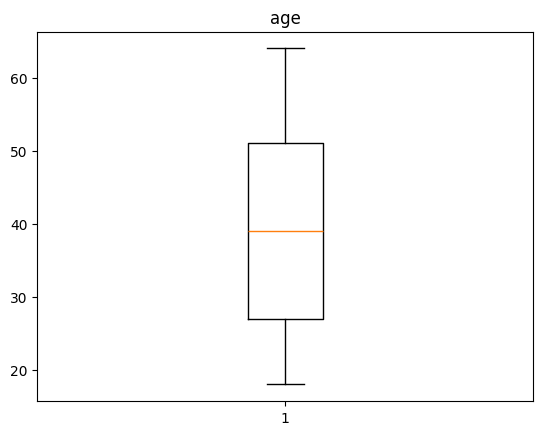

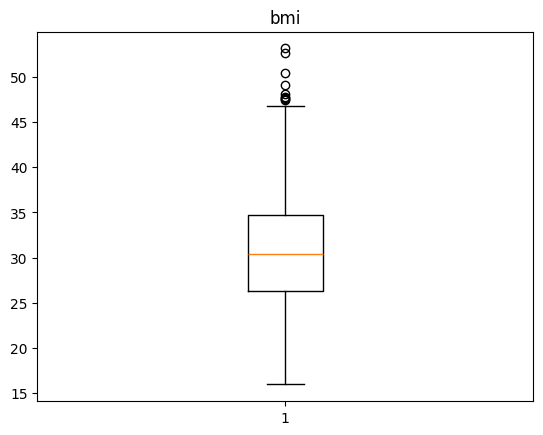

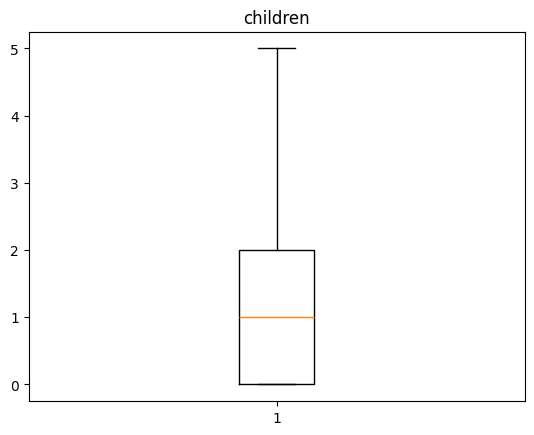

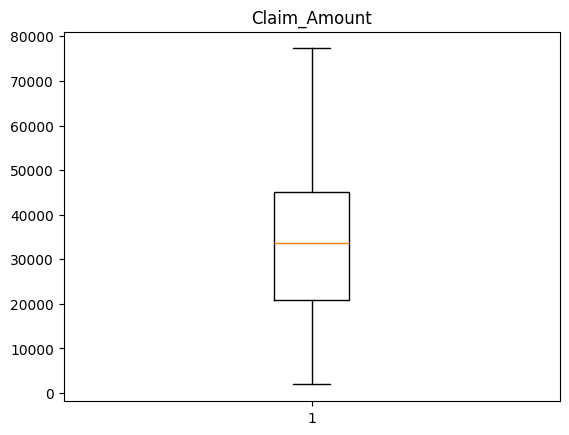

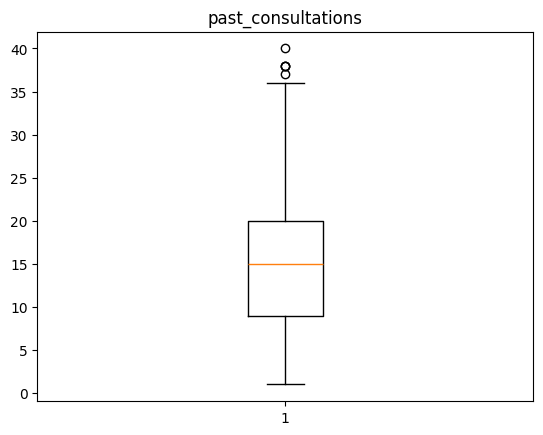

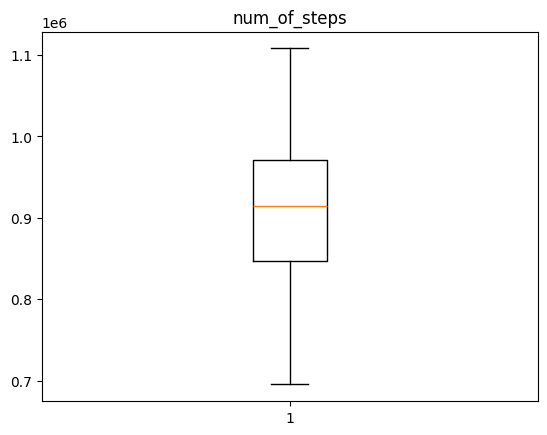

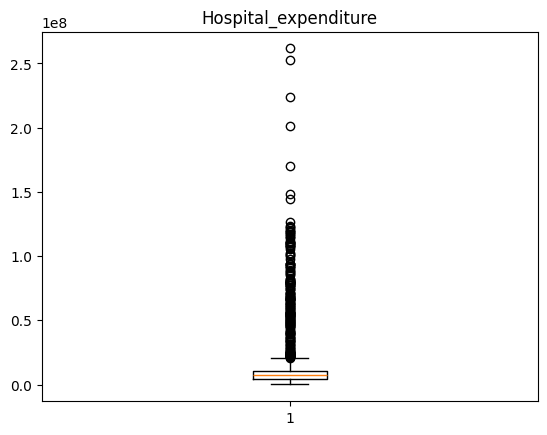

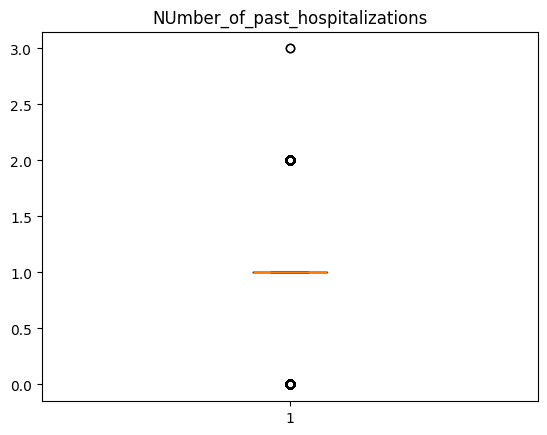

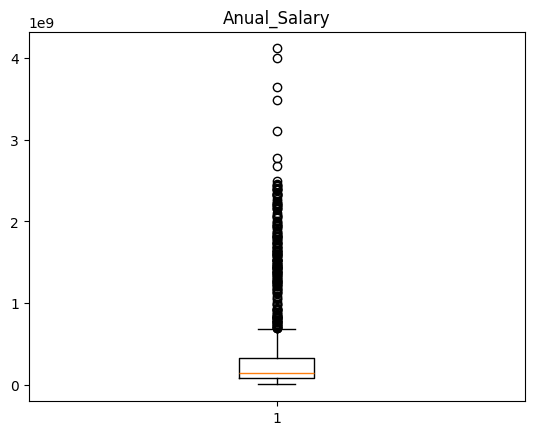

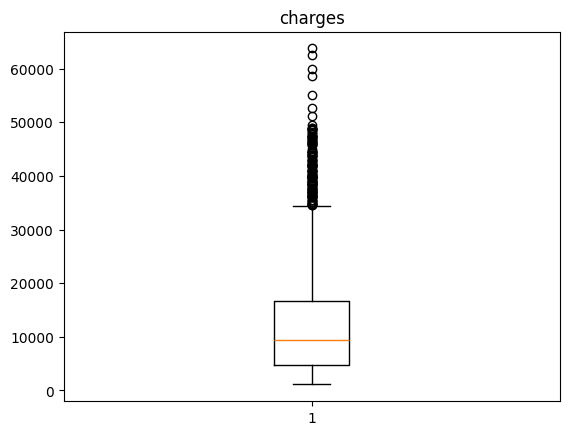

In [ ]:
for i in df.columns:
  if(df[i].dtype != 'object'):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
df['NUmber_of_past_hospitalizations'].nunique()

4

In [ ]:
df['NUmber_of_past_hospitalizations'].value_counts()

,count
NUmber_of_past_hospitalizations,
1.0,959
2.0,227
0.0,150
3.0,2


In [ ]:
df['Anual_Salary'].nunique()#if we have large unique value we can remove outliers

1092

In [ ]:
outliers=['bmi','past_consultations','Hospital_expenditure','Anual_Salary']

In [ ]:
#removing the outlier

In [ ]:
for i in outliers:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  IQR=q3-q1
  lb=q1-1.5*IQR
  ub=q3+1.5*IQR
  df=df[(df[i]>=lb)&(df[i]<=ub)]

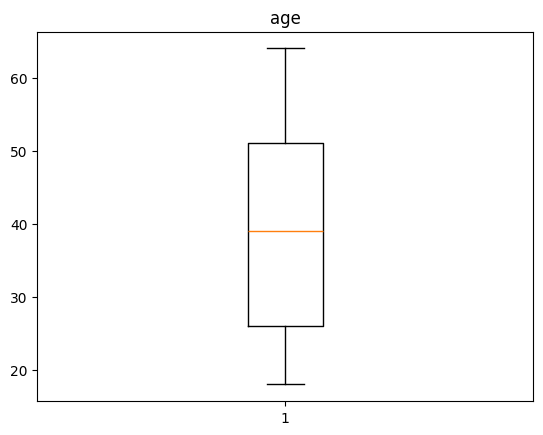

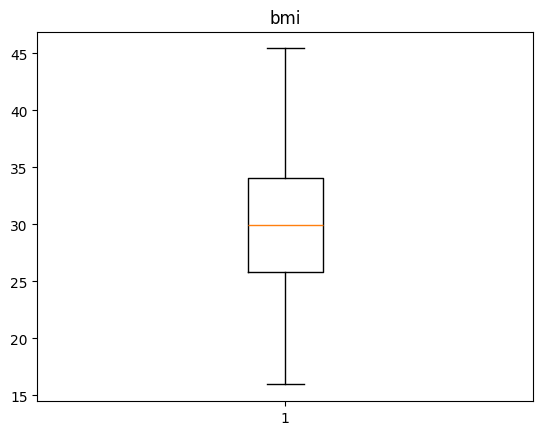

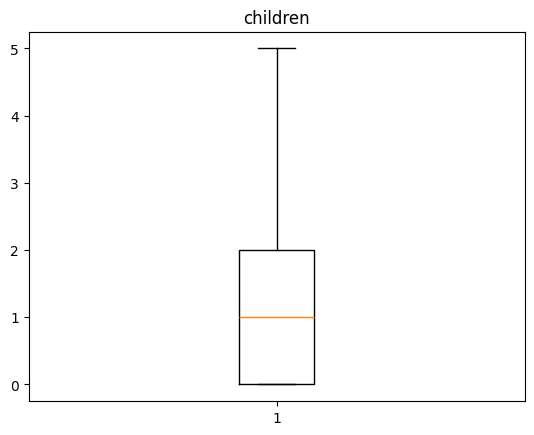

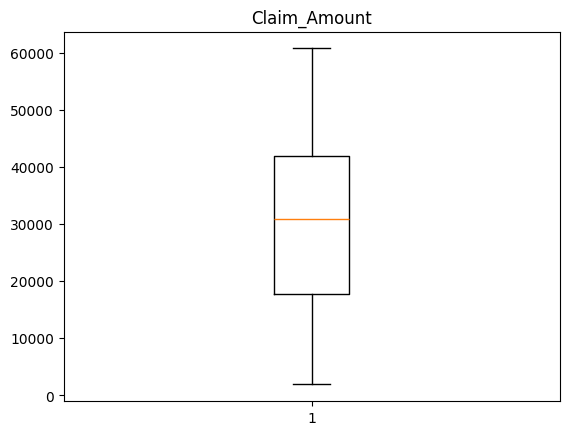

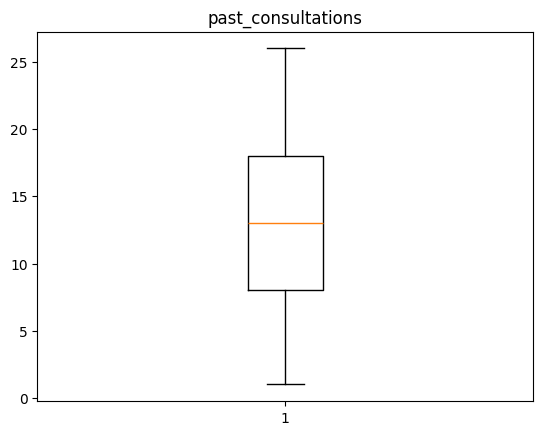

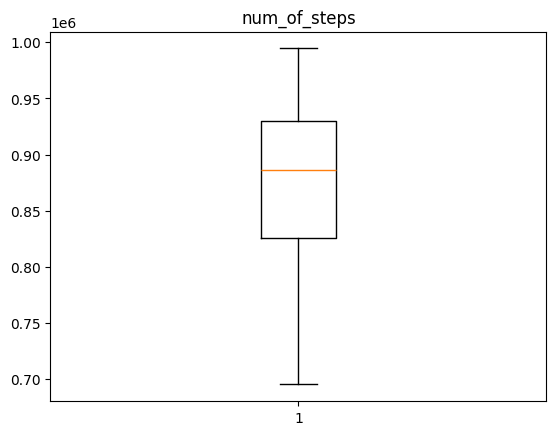

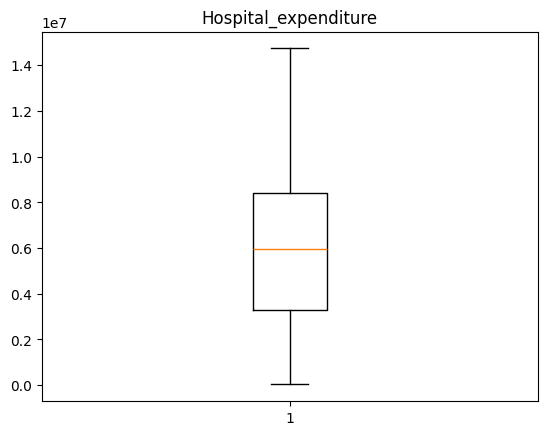

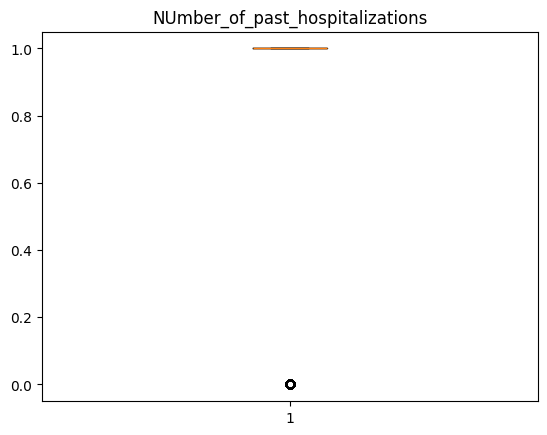

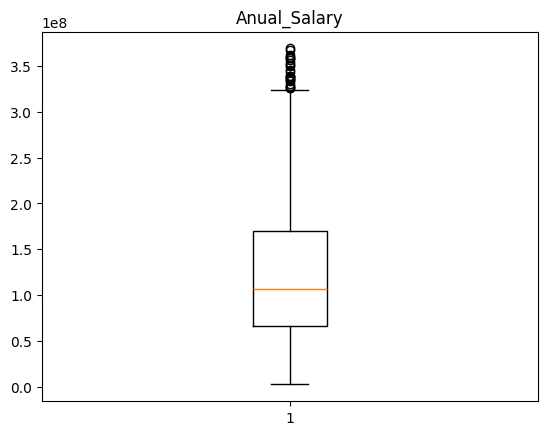

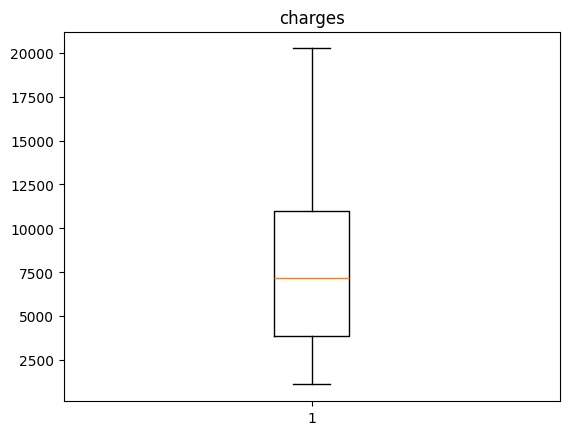

In [ ]:
for i in df.columns:
  if(df[i].dtype != 'object'):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1014 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1014 non-null   float64
 1   sex                              1014 non-null   object 
 2   bmi                              1014 non-null   float64
 3   children                         1014 non-null   float64
 4   smoker                           1014 non-null   object 
 5   Claim_Amount                     1014 non-null   float64
 6   past_consultations               1014 non-null   float64
 7   num_of_steps                     1014 non-null   float64
 8   Hospital_expenditure             1014 non-null   float64
 9   NUmber_of_past_hospitalizations  1014 non-null   float64
 10  Anual_Salary                     1014 non-null   float64
 11  region                           1014 non-null   object 
 12  charges                  

In [ ]:
df.shape

(1014, 13)

In [ ]:
#Label Encoding--->the model is trained on numeric data--->change the categorical/object --->numeric

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()
for i in df.columns:
  if(df[i].dtype =='object'):
    df[i]=le.fit_transform(df[i])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1014 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1014 non-null   float64
 1   sex                              1014 non-null   int64  
 2   bmi                              1014 non-null   float64
 3   children                         1014 non-null   float64
 4   smoker                           1014 non-null   int64  
 5   Claim_Amount                     1014 non-null   float64
 6   past_consultations               1014 non-null   float64
 7   num_of_steps                     1014 non-null   float64
 8   Hospital_expenditure             1014 non-null   float64
 9   NUmber_of_past_hospitalizations  1014 non-null   float64
 10  Anual_Salary                     1014 non-null   float64
 11  region                           1014 non-null   int64  
 12  charges                  

# BUilding the ml Model


In [ ]:
#import the libraries
#split data --->independent (x)and dependent(y)columns
#split the data for train test split
#test the model
#evaluating the model

In [ ]:
#lib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *

In [ ]:
#spliting x and y columns

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,23.0,0,28.490,1.0,1,19140.20117,23.0,978374.0,1.290713e+07,1.0,3.529098e+08,2,18328.23810
1034,24.0,1,29.830,0.0,1,35155.45242,17.0,979075.0,1.226416e+07,1.0,3.674079e+08,0,18648.42170
1036,43.0,1,20.130,2.0,1,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,2,18767.73770
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,1.419361e+08,0,19798.05455


In [ ]:
x=df.drop(columns='charges')

In [ ]:
print(x)

       age  sex     bmi  children  smoker  Claim_Amount  past_consultations  \
0     18.0    1  23.210       0.0       0   29087.54313                17.0   
1     18.0    1  30.140       0.0       0   39053.67437                 7.0   
2     18.0    1  33.330       0.0       0   39023.62759                19.0   
3     18.0    1  33.660       0.0       0   28185.39332                11.0   
4     18.0    1  34.100       0.0       0   14697.85941                16.0   
...    ...  ...     ...       ...     ...           ...                 ...   
1032  23.0    0  28.490       1.0       1   19140.20117                23.0   
1034  24.0    1  29.830       0.0       1   35155.45242                17.0   
1036  43.0    1  20.130       2.0       1   44184.65414                19.0   
1062  43.0    0  20.045       2.0       1   21596.43846                10.0   
1069  35.0    0  28.025       0.0       1   17200.14586                15.0   

      num_of_steps  Hospital_expenditure  NUmber_of

In [ ]:
y=df['charges']

In [ ]:
print(y)

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1032    18328.23810
1034    18648.42170
1036    18767.73770
1062    19798.05455
1069    20234.85475
Name: charges, Length: 1014, dtype: float64


In [ ]:
x.shape

(1014, 12)

In [ ]:
y.shape

(1014,)

In [ ]:
#spliting training and test

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [ ]:
"""np.random.seed(0)
np.random.randint(1,100,20)--->random_state is similar to random.seed"""

'np.random.seed(0)\nnp.random.randint(1,100,20)'

In [ ]:
x_train.shape

(811, 12)

In [ ]:
y_train.shape

(811,)

In [ ]:
x_test.shape

(203, 12)

In [ ]:
y_test.shape

(203,)

In [ ]:
#from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
#test the model

In [ ]:
yp=model.predict(x_test)

In [ ]:
print(yp)

[ 9858.32119942  6974.23893835  3420.79620314  8910.24554475
 12737.64002357  7393.90795043 12517.85367324  2861.65151573
  4520.77109275  9113.83259574  8008.38316122  6156.9467232
  9146.67398115  9694.3831837  10403.62313753  6473.76945796
 13184.24545956  5401.89697332  9534.89651747 10808.27603418
 10769.16965325  3597.59725132  4994.10062912 15437.18699731
 12663.01827665 12131.04492936  3917.08945647  2904.19982613
  4668.20422159  8672.54437082 12888.22071779  2758.37209298
   895.08870105  4324.40529162  6869.711209    9466.10903332
 13284.83631025  4129.07768801  2265.18352096  6812.26168961
  9778.91915088 12530.35815459  6824.47407576  7729.78107822
  5734.73438338   625.24159002 15788.15026623  3004.30510779
 -1410.53485657  5604.3590331  11989.04192614  7962.60966004
  5917.78740115  2532.08334475  8048.41917143 10549.52899868
  6706.41658815  9608.90769068   -21.48043705  6340.87821272
 13490.52781624  1012.23049918  6583.0949137    966.48231899
  1249.27464191 13031.730

In [ ]:
result=pd.DataFrame({'Actual value':y_test,'Predicted value':yp})
result["Actual value"]=y_test
result['Predicted value']=yp
result['error']=y_test-yp
print(result)

     Actual value  Predicted value       error
762   10848.13430      9858.321199  989.813101
525    7261.74100      6974.238938  287.502062
213    3277.16100      3420.796203 -143.635203
618    8596.82780      8910.245545 -313.417745
927   13462.52000     12737.640024  724.879976
..            ...              ...         ...
375    5246.04700      4813.846073  432.200927
386    5373.36425      4907.497358  465.866892
790   11289.10925     11388.448444  -99.339194
770   10977.20630     10385.397553  591.808747
691    9715.84100      9743.589974  -27.748974

[203 rows x 3 columns]


In [ ]:
#accuracy--->r2 score test

In [ ]:
r2_score(y_test,yp)*100
#r2 score--->1 it is good

95.97102169227568

In [ ]:
mean_squared_error(y_test,yp)

714971.8623134316

In [ ]:
mean_absolute_error(y_test,yp)

652.0760077966177

In [ ]:
root_mean_squared_error(y_test,yp)

845.5600879378304

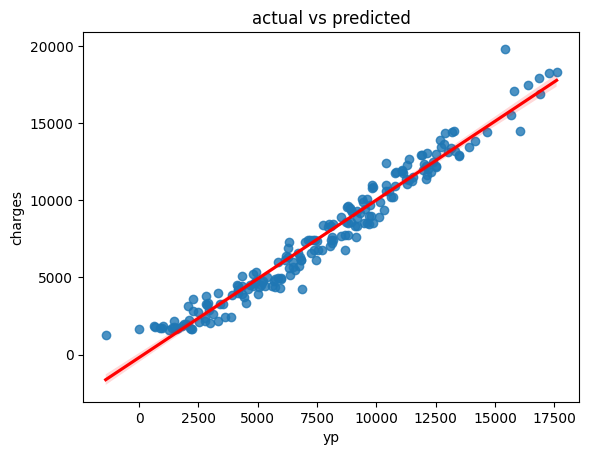

In [ ]:
sns.regplot(x=yp,y=y_test,line_kws={'color':'red'})
plt.xlabel('yp')
plt.ylabel('charges')
plt.title('actual vs predicted')
plt.show()